In [1]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np

from typing import Dict, List, Tuple, Optional
from itertools import permutations
from scipy.stats import percentileofscore

from pandas.tseries.offsets import DateOffset

from xbbg import blp
import re
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors




In [2]:
# -----------------------------------------------------------------------------------------------------------------------------
# ---------------------- CROSS CURRENCY ATM VOL CODE 
# -----------------------------------------------------------------------------------------------------------------------------

In [13]:
def get_ImplRealVol(currency_list, tenors, days_back):
    start_date = (datetime.now() - timedelta(days=days_back)).strftime("%Y-%m-%d")
    end_date   = datetime.now().strftime("%Y-%m-%d")
    series_dict = {} 
    vol_types = ["H", "V"] 
    for tenor in tenors:
        for ccy in currency_list:
            for vt in vol_types:
                ticker = f"{ccy}{vt}{tenor} Curncy"
                df = blp.bdh(
                    tickers=ticker,
                    flds="PX_LAST",
                    start_date=start_date,
                    end_date=end_date)
                df.columns = df.columns.get_level_values(1)
                s = df["PX_LAST"].astype(float).dropna()
                series_dict[(vt, tenor, ccy)] = s
    out = pd.concat(series_dict, axis=1, join="outer").sort_index()
    out.columns = [f"{ccy}_{vt}{tenor}" for (vt, tenor, ccy) in out.columns]
    return out

def get_Allvol_df(ccys, tenors, days_back):
    include_iv=True; include_hv=False
    df = get_ImplRealVol(ccys, tenors, days_back)
    out = {}   
    for ccy in ccys:
        for tenor in tenors:
            vcol = f"{ccy}_V{tenor}"
            hcol = f"{ccy}_H{tenor}"
            has_v = vcol in df.columns
            has_h = hcol in df.columns
            if has_v and has_h:
                pair = df[[vcol, hcol]]
                pair = pair.dropna() 
                spread = pair[vcol].astype(float) - pair[hcol].astype(float)
                out[("VDiff", tenor, ccy)] = spread
                if include_iv and has_v:
                    iv = df[vcol].astype(float).reindex(spread.index)
                    out[("IV", tenor, ccy)] = iv
                if include_hv and has_h:
                    hv = df[hcol].astype(float).reindex(spread.index) 
                    out[("HV", tenor, ccy)] = hv
            else:
                if include_iv and has_v:
                    iv = df[vcol].astype(float)
                    iv = iv.dropna()
                    out[("IV", tenor, ccy)] = iv
    res = pd.concat(out, axis=1).sort_index()
    res.columns = [f"{ccy}_{tenor}_{metric}" for (metric, tenor, ccy) in res.columns]
    return res

def ATM_VolRefferenceRanking_AllTenorCCY_FullTimePannel(currency_list, tenors, lookback_days):
    def xCCY_AllPairs_MultiTenor_Analysis(currency_list: List[str], tenor_list: List[str]):
        end_date = datetime.now().strftime("%Y-%m-%d")
        start_date = (datetime.now() - timedelta(days=lookback_days)).strftime("%Y-%m-%d")
        base_ccy = sorted(set(currency_list))  
        results_by_tenor: Dict[str, pd.DataFrame] = {}
        currency_avg_metrics: Dict[str, pd.DataFrame] = {}
        correlation_data: Dict[str, pd.DataFrame] = {}  
        df_all_by_tenor: Dict[str, pd.DataFrame] = {} 
        for tenor in tenor_list:
            data_dict: Dict[str, pd.Series] = {}
            for ccy_pair in base_ccy:  
                ticker_IV = f"{ccy_pair}V{tenor} BGN Curncy"
                try:
                    data_IV = blp.bdh(
                        tickers=ticker_IV,
                        flds="PX_LAST",
                        start_date=start_date,
                        end_date=end_date)
                    data_IV.columns = data_IV.columns.get_level_values(1)
                    data_dict[ccy_pair] = data_IV['PX_LAST']
                except Exception as e:
                    continue
            if not data_dict:
                continue
            df_all = pd.DataFrame(data_dict).dropna()
            if df_all.empty:
                continue
            df_all_by_tenor[tenor] = df_all
            correlation_matrix = df_all.diff().dropna().corr()
            correlation_data[tenor] = correlation_matrix
            latest_date = df_all.index[-1]
            currency_pairs = list(permutations(base_ccy, 2))
            pair_results = []
            currency_volatilities: Dict[str, List[Dict[str, float]]] = {ccy_pair: [] for ccy_pair in base_ccy}
            for ccy_pair1, ccy_pair2 in currency_pairs: 
                if ccy_pair1 not in df_all.columns or ccy_pair2 not in df_all.columns:
                    continue
                current_spread = df_all.loc[latest_date, ccy_pair1] - df_all.loc[latest_date, ccy_pair2]
                historical_spreads = df_all[ccy_pair1] - df_all[ccy_pair2]
                Percentile_lookback = percentileofscore(historical_spreads, current_spread)
                STD_lookback = historical_spreads.std()
                mean_lookback = historical_spreads.mean()
                ZScore_lookback = abs(current_spread - mean_lookback) / STD_lookback 
                correlation = correlation_matrix.loc[ccy_pair1, ccy_pair2] if (ccy_pair1 in correlation_matrix.index and ccy_pair2 in correlation_matrix.columns) else None
                pair_result = {
                    'Tenor': tenor,
                    'Pair': f"{ccy_pair1}-{ccy_pair2}",
                    'CCY1': ccy_pair1,  # Now this is a currency pair like 'EURUSD'
                    'CCY2': ccy_pair2,  # Now this is a currency pair like 'USDJPY'
                    'Correlation': round(correlation, 4) if correlation is not None else None,
                    'Current_Spread': round(current_spread, 4),
                    'Spread_Mean': round(mean_lookback, 4) if mean_lookback is not None else None,
                    'Spread_STD': round(STD_lookback, 4) if STD_lookback is not None else None,
                    'ZScore_current': round(ZScore_lookback, 4) if ZScore_lookback is not None else None,
                    'Percentile_current': round(Percentile_lookback, 3) if Percentile_lookback is not None else None}
                pair_results.append(pair_result)
            results_by_tenor[tenor] = pd.DataFrame(pair_results)
        return results_by_tenor
    def find_ave_allCCYallLookback_correlationWeights(results_by_tenor, tenors):
        tenor_results = {}  
        for tenor in tenors:
            if tenor in results_by_tenor:
                df = results_by_tenor[tenor]
                all_currency_pairs = set(df['CCY1'].tolist() + df['CCY2'].tolist())
                currency_percentile_summary = []
                for ccy_pair in all_currency_pairs:  # ccy_pair is like 'EURUSD'
                    ccy_pairs = df[df['CCY1'] == ccy_pair].copy()  # All pairs where EURUSD is first
                    if len(ccy_pairs) > 0:
                        ccy_pairs_valid = ccy_pairs.dropna(subset=['Correlation'])
                        if len(ccy_pairs_valid) == 0:
                            weights = np.ones(len(ccy_pairs)) / len(ccy_pairs)
                            ccy_pairs_for_calc = ccy_pairs
                        else:
                            correlation_weights = ccy_pairs_valid['Correlation'].abs()  # Use absolute correlation
                            weights = correlation_weights / correlation_weights.sum()  # Normalize to sum to 1
                            ccy_pairs_for_calc = ccy_pairs_valid
                        weighted_avg_percentile_Lookback = np.average(ccy_pairs_for_calc['Percentile_current'], weights=weights)
                        currency_percentile_summary.append({
                            'Currency_Pair': ccy_pair,  # Updated column name for clarity
                            'Tenor': tenor,
                            'Avg_CorrWeight%': round(weighted_avg_percentile_Lookback, 3),
                            'Num_Pairs': len(ccy_pairs)})
                percentile_df = pd.DataFrame(currency_percentile_summary).sort_values('Avg_CorrWeight%')
                tenor_results[tenor] = percentile_df
        return tenor_results
    results_by_tenor  = xCCY_AllPairs_MultiTenor_Analysis(currency_list, tenors)   
    ave_tenorBuckets_correlationWeighted = find_ave_allCCYallLookback_correlationWeights(results_by_tenor, tenors)
    return {'results_by_tenor': results_by_tenor,
            'ave_results_by_tenor_correlationWeighted': ave_tenorBuckets_correlationWeighted}

def get_ccy_corrweight_by_tenor(ccy, xCCY_fullData):
    xCCY_MarketAgg = xCCY_fullData['ave_results_by_tenor_correlationWeighted']
    data = []
    for tenor, df in xCCY_MarketAgg.items():
        row = df.loc[df["Currency_Pair"] == ccy]
        if not row.empty:
            data.append([
                tenor,
                row["Avg_CorrWeight%"].iloc[0]])
    out = pd.DataFrame(data, columns=["Tenor", "Avg_CorrWeight%"])
    out = (out.sort_values("Tenor",
            key=lambda x: x.map({"1W":1, "2W":2, "1M":3, "3M":4, "6M":5, "1Y":6}))
            .set_index("Tenor"))
    return out



def getCCY_xCCYVolMetric(ccy, tenors, voldata, xCCY_fullData):
    ccy = ccy[0]
    market_rel_df = get_ccy_corrweight_by_tenor(ccy, xCCY_fullData)
    results = []
    for tenor in tenors:
        iv_col = f"{ccy}_{tenor}_IV"
        vdiff_col = f"{ccy}_{tenor}_VDiff"
        row_data = {'Tenor': tenor}
        if iv_col in voldata.columns:
            iv_series = voldata[iv_col].dropna()
            if len(iv_series) > 0:
                current_iv = iv_series.iloc[-1]
                iv_percentile = (iv_series < current_iv).sum() / len(iv_series) * 100
                row_data['IV'] = round(current_iv, 2)
                row_data['IV %'] = round(iv_percentile, 2)
            else:
                row_data['IV'] = None
                row_data['IV %'] = None
        else:
            row_data['IV'] = None
            row_data['IV %'] = None
        if vdiff_col in voldata.columns:
            vdiff_series = voldata[vdiff_col].dropna()
            if len(vdiff_series) > 0:
                current_vdiff = vdiff_series.iloc[-1]
                vdiff_percentile = (vdiff_series < current_vdiff).sum() / len(vdiff_series) * 100
                row_data['I-R'] = round(current_vdiff, 2)
                row_data['I-R %'] = round(vdiff_percentile, 2)
            else:
                row_data['I-R'] = None
                row_data['I-R %'] = None
        else:
            row_data['I-R'] = None
            row_data['I-R %'] = None
        if tenor in market_rel_df.index:
            row_data['xCCY_MarketRel'] = market_rel_df.loc[tenor, 'Avg_CorrWeight%']
        else:
            row_data['xCCY_MarketRel'] = None
        results.append(row_data)
    out = pd.DataFrame(results)
    out = out.set_index('Tenor')
    return out.reset_index()



def getCCY_xCCYSpreadMetrics(CCY_Interest, tenor_interest, xCCY_fullData):
    CCY_Interest = CCY_Interest[0]
    xCCY_AllSpreads = xCCY_fullData["results_by_tenor"]
    df_singleTenor = xCCY_AllSpreads[tenor_interest]
    df_messy = df_singleTenor[df_singleTenor["CCY1"] == CCY_Interest]
    dfclean = df_messy[['Pair', 'Tenor', 'Current_Spread', 'Correlation', 'Percentile_current', 'Spread_Mean', 'Spread_STD']]
    dfclean = dfclean.rename(
        columns={
            "Current_Spread": "Spread",
            "Percentile_current": f"Spread %",
            "Spread_Mean": f"Spread Mean",
            "Spread_STD": f"Spread STD"})
    dfclean = dfclean.sort_values(by=f"Correlation", ascending=False)
    return dfclean

In [ ]:
# -----------------------------------------------------------------------------------------------------------------------------
# ---------------------- RR CODE 
# -----------------------------------------------------------------------------------------------------------------------------

In [4]:
def BaseVolAdjRRDataDaily(ccy, tenor,  delta):
    start_date = (datetime.today() - timedelta(days=(365 * 5))).strftime('%Y-%m-%d')
    end_date = datetime.today().strftime('%Y-%m-%d')
    ticker_IV = f"{ccy}V{tenor} BGN Curncy"
    field = "PX_LAST"
    data_IV = blp.bdh(
        tickers=ticker_IV,
        flds=field,
        start_date=start_date,
        end_date=end_date)
    ticker_RR = f"{ccy}{delta}R{tenor} BGN Curncy" 
    field = "PX_LAST"
    data_RR = blp.bdh(
        tickers=ticker_RR,
        flds=field,
        start_date=start_date,
        end_date=end_date)
    combined_data = pd.concat([data_IV, data_RR], axis=1)
    combined_data.columns = [f'V{tenor}', f'{delta}r{tenor}']
    combined_data[f'{tenor}_VolAdjRR'] = combined_data[f'{delta}r{tenor}'] / combined_data[f'V{tenor}']
    return combined_data
def _z_score(series, x):
    mu    = series.mean()
    sigma = series.std(ddof=0)       
    return np.nan if sigma == 0 else (x - mu) / sigma
def BaseVolAdjRREval(ccy, tenors, delta):
    df_all = pd.DataFrame()
    for tenor in tenors:
        df_tenor = BaseVolAdjRRDataDaily(ccy, tenor, delta)
        df_all   = df_tenor if df_all.empty else df_all.join(df_tenor, how="outer")
    df_all.index = pd.to_datetime(df_all.index)
    latest_rows = []
    for tenor in tenors:
        latest_rows.append({
            "Tenor"            : tenor,
            f"{delta}D RR"     : df_all[f"{delta}r{tenor}"].iloc[-1],
            "ATM Vol"          : df_all[f"V{tenor}"].iloc[-1],
            "VolAdjRR"         : df_all[f"{tenor}_VolAdjRR"].iloc[-1],})
    df_latest = pd.DataFrame(latest_rows)
    end   = df_all.index[-1]
    cut_3m  = end - pd.DateOffset(months=3)
    cut_1y  = end - pd.DateOffset(years=1)
    cut_5y  = end - pd.DateOffset(years=5)
    score_rows = []
    for tenor in df_latest["Tenor"]:
        col = f"{tenor}_VolAdjRR"
        current = df_latest.loc[df_latest["Tenor"] == tenor, "VolAdjRR"].values[0]
        score_rows.append({
            "Tenor"          : tenor,
            "3M Z-Score"     : _z_score(df_all.loc[df_all.index >= cut_3m,  col], current),
            "1Y Z-Score"     : _z_score(df_all.loc[df_all.index >= cut_1y,  col], current),
            "5Y Z-Score"     : _z_score(df_all.loc[df_all.index >= cut_5y,  col], current)})
    df_scores = pd.DataFrame(score_rows)
    out = (
        pd.merge(df_latest, df_scores, on="Tenor")
          .rename(columns={
              f"{delta}D RR"        : "25D Risk Reversal",
              "ATM Vol"             : "At-The-Money Volatility",
              "VolAdjRR"            : "Volatility Adjusted RR",})
          .round({"3M Z-Score": 2, "1Y Z-Score": 2,
                  "5Y Z-Score": 2})
          .set_index("Tenor"))
    return out
def multipleCcyAdjRRSorted(currency_pairs, tenors, delta):
    frames = []
    for ccy in currency_pairs:
        df_ccy = BaseVolAdjRREval(ccy, tenors, delta)
        df_ccy["Currency Pair"] = ccy              # tag the pair
        frames.append(df_ccy)
    combined = (
        pd.concat(frames)           # index = Tenor -> row index
          .reset_index()            # Tenor back to a column
          .loc[:, ["Currency Pair", "Tenor",
                   "Volatility Adjusted RR",
                   "3M Z-Score", "1Y Z-Score",
                   "5Y Z-Score"]])
    combined.columns = [
        "Pair", "Tenor", "Vol Adj 25RR",
        "3M ZScore", "1Y ZScore", "5Y ZScore"]
    combined["Vol Adj 25RR"] = (combined["Vol Adj 25RR"] * 100).round(3)

    return combined

In [ ]:
# -----------------------------------------------------------------------------------------------------------------------------
# ---------------------- BF CODE 
# -----------------------------------------------------------------------------------------------------------------------------

In [5]:
def BaseVolAdjBFDataDaily(ccy, tenor, delta):
    start_date = (datetime.today() - timedelta(days=(365 * 5))).strftime('%Y-%m-%d')
    end_date = datetime.today().strftime('%Y-%m-%d')
    ticker_IV = f"{ccy}V{tenor} BGN Curncy"
    field = "PX_LAST"
    data_IV = blp.bdh(
        tickers=ticker_IV,
        flds=field,
        start_date=start_date,
        end_date=end_date)
    ticker_BF = f"{ccy}{delta}B{tenor} BGN Curncy" # 
    field = "PX_LAST"
    data_BF = blp.bdh(
        tickers=ticker_BF,
        flds=field,
        start_date=start_date,
        end_date=end_date)
    combined_data = pd.concat([data_IV, data_BF], axis=1)
    combined_data.columns = [f'V{tenor}', f'{delta}b{tenor}']
    combined_data[f'{tenor}_VolAdjBF'] = combined_data[f'{delta}b{tenor}'] / combined_data[f'V{tenor}']
    return combined_data
def BaseVolAdjBFEval(ccy, tenors, delta):
    df_allVolAdjBFs = pd.DataFrame()
    for tenor in tenors:
        df_tenor = BaseVolAdjBFDataDaily(ccy, tenor,  delta)
        if df_allVolAdjBFs.empty:
            df_allVolAdjBFs = df_tenor
        else:
            df_allVolAdjBFs = df_allVolAdjBFs.join(df_tenor, how='outer')
    tenor_data = []
    for tenor in tenors:
        tenor_row = {
            'Tenor': tenor,
            f'{delta}D BF': df_allVolAdjBFs[f'{delta}b{tenor}'].iloc[-1],  # Latest 25D RBF
            'ATM Vol': df_allVolAdjBFs[f'V{tenor}'].iloc[-1],   # Latest ATM Vol
            'VolAdjBF': df_allVolAdjBFs[f'{tenor}_VolAdjBF'].iloc[-1]}
        tenor_data.append(tenor_row)
    df_reshaped = pd.DataFrame(tenor_data)
    df_allVolAdjBFs.index = pd.to_datetime(df_allVolAdjBFs.index)
    three_months_ago = pd.Timestamp(df_allVolAdjBFs.index[-1]) - pd.DateOffset(months=3)
    one_year_ago = pd.Timestamp(df_allVolAdjBFs.index[-1]) - pd.DateOffset(years=1)
    five_year_ago = pd.Timestamp(df_allVolAdjBFs.index[-1]) - pd.DateOffset(years=5)
    percentile_data = []
    for tenor in df_reshaped['Tenor']:
        vol_adj_bf_col = f'{tenor}_VolAdjBF'
        past_3m_data = df_allVolAdjBFs.loc[df_allVolAdjBFs.index >= three_months_ago, vol_adj_bf_col]
        past_1y_data = df_allVolAdjBFs.loc[df_allVolAdjBFs.index >= one_year_ago, vol_adj_bf_col]
        past_5y_data = df_allVolAdjBFs.loc[df_allVolAdjBFs.index >= five_year_ago, vol_adj_bf_col]
        current_value = df_reshaped.loc[df_reshaped['Tenor'] == tenor, 'VolAdjBF'].values[0]
        three_months_percentile = np.sum(past_3m_data < current_value) / len(past_3m_data) * 100
        one_year_percentile = np.sum(past_1y_data < current_value) / len(past_1y_data) * 100
        five_year_percentile = np.sum(past_5y_data < current_value) / len(past_5y_data) * 100
        percentile_data.append({
            'Tenor': tenor,
            '3M %': round(three_months_percentile, 2),
            '1Y %': round(one_year_percentile, 2),
            '5Y %': round(five_year_percentile, 2)})
    df_percentiles = pd.DataFrame(percentile_data)
    df_reshaped = pd.merge(df_reshaped, df_percentiles, on='Tenor')
    return df_reshaped
def multipleCCYAdjBFSorted(currency_pairs, tenors, delta):
    combined_df = pd.DataFrame()
    for ccy in currency_pairs:
        df_ccy = BaseVolAdjBFEval(ccy, tenors, delta)
        df_ccy['Pair'] = ccy
        combined_df = pd.concat([combined_df, df_ccy], ignore_index=False)
    combined_df.reset_index(inplace=True)
    combined_df = combined_df[['Pair', 'Tenor',  
                                    'VolAdjBF', 
                                    '3M %', '1Y %',
                                    '5Y %']]
    
    combined_df = combined_df.rename(
        columns={
            'VolAdjBF':'Vol Adj 10BF'})
    
    combined_df["Vol Adj 10BF"] = (combined_df["Vol Adj 10BF"] * 100).round(3)
    return combined_df

In [ ]:
# -----------------------------------------------------------------------------------------------------------------------------
# ---------------------- Term Structure 
# -----------------------------------------------------------------------------------------------------------------------------

In [6]:
def calculate_term_percentiles(ccys):
    tenors = ['1W', '2W', '1M', '3M', '6M', '1Y']
    spreads = [
            # Upcoming Event Risk Measurments 
            ('1W', '2W'),
            ('1W', '1M'),
            ('1W', '3M'), # Event/Gamma vs Macro Risk 

            # Macro Slope - Is uncertainty growing with time 
            ('1M', '3M'), 
            ('1M', '6M'),

            # Medium term Risk - Will it fade out?
            ('3M', '1Y'),
            ('6M', '1Y')]
    results = {}
    for ccy in ccys:
        end_date = datetime.now().strftime("%Y-%m-%d")
        start_date = (datetime.now() - timedelta(days=365 * 5)).strftime("%Y-%m-%d")
        df_vols = {}
        for tenor in tenors:
            ticker_IV = f"{ccy}V{tenor} BGN Curncy"
            data_IV = blp.bdh(
                tickers=ticker_IV,
                flds="PX_LAST",
                start_date=start_date,
                end_date=end_date)
            if not data_IV.empty:
                data_IV.columns = [tenor]
                df_vols[tenor] = data_IV
            else:
                print(f"No data for {ticker_IV}, skipping.")
        df_vols_all = pd.concat(df_vols.values(), axis=1)
        df_spreads = pd.DataFrame(index=df_vols_all.index)
        for spread in spreads:
            first_tenor, second_tenor = spread
            spread_name = f"{first_tenor}-{second_tenor}"
            df_spreads[spread_name] = df_vols_all[first_tenor] - df_vols_all[second_tenor]
        three_months_ago = (df_spreads.index[-1] - DateOffset(months=3)).date()
        one_year_ago = (df_spreads.index[-1] - DateOffset(years=1)).date()
        three_year_ago = (df_spreads.index[-1] - DateOffset(years=3)).date()
        df_spreads_3m = df_spreads[df_spreads.index >= three_months_ago]
        df_spreads_1Y = df_spreads[df_spreads.index >= one_year_ago]
        df_spreads_3Y = df_spreads[df_spreads.index >= three_year_ago]
        current_spread = df_spreads.iloc[-1]
        spread_data = {}
        for column in df_spreads.columns:
            actual_value = current_spread[column]
            percentiles_3M = np.sum(df_spreads_3m[column] < actual_value) / df_spreads_3m[column].count() * 100
            percentiles_1Y = np.sum(df_spreads_1Y[column] < actual_value) / df_spreads_1Y[column].count() * 100
            percentiles_3Y = np.sum(df_spreads_3Y[column] < actual_value) / df_spreads_3Y[column].count() * 100
            percentiles_5Y = np.sum(df_spreads[column] < actual_value) / df_spreads[column].count() * 100

            spread_data[column] = {
                "Current Spread": round(actual_value, 4),
                "3M %": round(percentiles_3M, 2),
                "1Y %": round(percentiles_1Y, 3),
                "3Y %": round(percentiles_3Y, 4),
                "5Y %": round(percentiles_5Y, 5)}
        results[ccy] = pd.DataFrame.from_dict(spread_data, orient="index")
    combined_df = []
    for ccy, df_summary in results.items():
        df_summary['CCY'] = ccy
        combined_df.append(df_summary)
    final_df = pd.concat(combined_df, axis=0)
    final_df.reset_index(inplace=True)
    final_df.rename(columns={'index': 'Spread'}, inplace=True)
    df = final_df[['Spread', 'CCY', 'Current Spread', '3M %', '1Y %', '3Y %', '5Y %']]
    return df

In [ ]:
# -----------------------------------------------------------------------------------------------------------------------------
# ---------------------- ECO DATA 
# -----------------------------------------------------------------------------------------------------------------------------

In [ ]:
class EconomicDataManager:
    FIELD_RENAME_MAP = {
        "eco_release_dt": "ReleaseDate",
        "actual_release": "Actual", 
        "bn_survey_median": "SMed",
        "forecast_standard_deviation": "ForecastSDTv"}
    def __init__(self, bloomberg_api, indicators_dict: Optional[Dict] = None):
        self.blp = bloomberg_api
        self.indicators = indicators_dict or {}
    def add_indicators(self, currency_code: str, indicators: List[Dict]) -> None:
        self.indicators[currency_code] = indicators
    def parse_time_period(self, period_str: str) -> int:
        if not isinstance(period_str, str):
            raise ValueError("Period must be a string")
        period_str = period_str.strip().lower()
        match = re.match(r'^(\d+)([wm])$', period_str)
        if not match:
            raise ValueError(
                f"Invalid period format: '{period_str}'. "
                f"Use format like '1w', '2W', '3m', '1M' (w=weeks, m=months)")
        number = int(match.group(1))
        unit = match.group(2)
        if unit == 'w':  
            return number * 7
        elif unit == 'm':  
            return number * 30
        else:
            raise ValueError(f"Unsupported time unit: {unit}")
    def _add_week_grouping(self, df: pd.DataFrame) -> pd.DataFrame:
        today = pd.Timestamp.today().normalize()
        start_of_this_week = today - pd.Timedelta(days=today.weekday())
        df["Week"] = ((df["Release Date"] - start_of_this_week).dt.days // 7).clip(lower=0)
        return df
    
    def get_futureData(self, ticker: str, days) -> pd.DataFrame:
        startDate_dataPull = datetime.today() - timedelta(days=200)
        endDate_dataPull = datetime.today() + timedelta(days=100)
        try:
            data = self.blp.bdh(
                tickers=ticker,
                flds= ["eco_release_dt", "actual_release", "bn_survey_median",  "forecast_standard_deviation"],
                start_date=startDate_dataPull.strftime('%Y-%m-%d'),
                end_date=endDate_dataPull.strftime('%Y-%m-%d'))
            if data.empty:
                return pd.DataFrame()
            if hasattr(data.columns, 'nlevels') and data.columns.nlevels > 1:
                data.columns = data.columns.droplevel(0)
            data = data.rename(columns=self.FIELD_RENAME_MAP)
            if 'ReleaseDate' in data.columns:
                data['ReleaseDate'] = pd.to_datetime(
                    data['ReleaseDate'].astype(str).str.split('.').str[0],
                    format='%Y%m%d',
                    errors='coerce')
                today = datetime.today().date()
                target_date = today + timedelta(days=days)
                data = data[data['ReleaseDate'].dt.date < target_date]
                data = data[data['ReleaseDate'].dt.date >= today]
                data = data.sort_values('ReleaseDate')
            return data
        except Exception as e:
            print(f"Error getting future data for {ticker}: {str(e)}")
            return pd.DataFrame()
    # DATE OF EVENT Functions
    def get_nextRelease(self, ticker: str, days: int = 100) -> Optional[str]:
        try:
            future_df = self.get_futureData(ticker, days)
            if future_df.empty or 'ReleaseDate' not in future_df.columns:
                return None
            return str(future_df.iloc[0]['ReleaseDate'].date())
        except Exception as e:
            print(f"Error getting next release for {ticker}: {str(e)}")
            return None
    # SCHEDULE OF EVENTS Functions
    def get_release_schedule(self, indicators: List[Dict], days: int = 100) -> pd.DataFrame:
        results = []
        failed_tickers = []
        for indicator in indicators:
            try:
                release_date = self.get_nextRelease(indicator["Ticker"], days)
                if release_date:  # Only add if we got a valid date
                    results.append({
                        "Country": indicator["Country"],
                        "Data": indicator["Data"], 
                        "Ticker": indicator["Ticker"],
                        "Release Date": release_date})
                else:
                    failed_tickers.append(indicator["Ticker"])
            except Exception as e:
                print(f"Warning: Could not get release date for {indicator['Ticker']}: {str(e)}")
                failed_tickers.append(indicator["Ticker"])
                continue
        if failed_tickers:
            print(f"Could not get release dates for {len(failed_tickers)} tickers: {failed_tickers[:5]}{'...' if len(failed_tickers) > 5 else ''}")
        if not results:
            print("No release dates found for any indicators")
            return pd.DataFrame(columns=["Country", "Data", "Ticker", "Release Date", "Weekday", "Week"])
        df = pd.DataFrame(results)
        print(f"Found {len(df)} release dates out of {len(indicators)} indicators")
        df["Release Date"] = pd.to_datetime(df["Release Date"], errors='coerce')
        df = df.dropna(subset=["Release Date"])
        if df.empty:
            print("No valid release dates after datetime conversion")
            return pd.DataFrame(columns=["Country", "Data", "Ticker", "Release Date", "Weekday", "Week"])
        df = df.sort_values(by="Release Date")
        df.insert(
            loc=df.columns.get_loc("Release Date") + 1,
            column="Weekday", 
            value=df["Release Date"].dt.day_name().str[:3])
        df = self._add_week_grouping(df)
        return df
    # UTILITY Functions
    def filter_by_date_range(self, df: pd.DataFrame, start_date: str, end_date: str) -> pd.DataFrame:
        start = pd.to_datetime(start_date)
        end = pd.to_datetime(end_date)
        return df[(df['Release Date'] >= start) & (df['Release Date'] <= end)]
    def _add_week_grouping(self, df: pd.DataFrame) -> pd.DataFrame:
        today = pd.Timestamp.today().normalize()
        start_of_this_week = today - pd.Timedelta(days=today.weekday())
        df["Week"] = ((df["Release Date"] - start_of_this_week).dt.days // 7).clip(lower=0)
        return df
    def test_ticker_availability(self, tickers: List[str], days: int = 30) -> Dict[str, bool]:
        """Test which tickers actually return data"""
        results = {}
        for ticker in tickers:
            try:
                data = self.get_futureData(ticker, days)
                results[ticker] = not data.empty
            except:
                results[ticker] = False
        return results
    # CURRENCY SPECIFIC Functions
    def get_currency_schedule(self, currency_code: str, days: int = 100) -> pd.DataFrame:
        if currency_code not in self.indicators:
            raise ValueError(f"Currency code '{currency_code}' not found in indicators")
        return self.get_release_schedule(self.indicators[currency_code], days)

    def get_all_currencies_schedule(self, days: int = 100) -> pd.DataFrame:
        all_indicators = []
        for currency_indicators in self.indicators.values():
            all_indicators.extend(currency_indicators)
        return self.get_release_schedule(all_indicators, days)
    def get_currency_pair_schedule(self, currency_pair: str, days: int = 100) -> pd.DataFrame:
        if len(currency_pair) != 6:
            raise ValueError(f"Currency pair '{currency_pair}' must be exactly 6 characters (e.g., 'EURUSD')")
        base_currency = currency_pair[:3].upper()
        quote_currency = currency_pair[3:].upper()
        missing_currencies = []
        if base_currency not in self.indicators:
            missing_currencies.append(base_currency)
        if quote_currency not in self.indicators:
            missing_currencies.append(quote_currency)
        if missing_currencies:
            available = list(self.indicators.keys())
            raise ValueError(
                f"Currency(ies) {missing_currencies} not found in indicators. "
                f"Available currencies: {available}")
        combined_indicators = []
        combined_indicators.extend(self.indicators[base_currency])
        combined_indicators.extend(self.indicators[quote_currency])
        schedule_df = self.get_release_schedule(combined_indicators, days)
        if not schedule_df.empty:
            schedule_df.insert(0, 'Currency Pair', currency_pair)
            def classify_currency(row):
                country = row['Country']
                for indicator in self.indicators[base_currency]:
                    if indicator['Country'] == country and indicator['Data'] == row['Data']:
                        return base_currency
                return quote_currency
            schedule_df.insert(1, 'Currency', schedule_df.apply(classify_currency, axis=1))
            schedule_df = schedule_df.sort_values('Release Date').reset_index(drop=True)
        return schedule_df
    
    def get_currency_pair_schedule(self, currency_pair: str, days: int = 100) -> pd.DataFrame:
        if len(currency_pair) != 6:
            raise ValueError(f"Currency pair '{currency_pair}' must be exactly 6 characters (e.g., 'EURUSD')")
        
        base_currency = currency_pair[:3].upper()
        quote_currency = currency_pair[3:].upper()
        
        missing_currencies = []
        if base_currency not in self.indicators:
            missing_currencies.append(base_currency)
        if quote_currency not in self.indicators:
            missing_currencies.append(quote_currency)
        
        if missing_currencies:
            available = list(self.indicators.keys())
            raise ValueError(
                f"Currency(ies) {missing_currencies} not found in indicators. "
                f"Available currencies: {available}")
        
        combined_indicators = []
        combined_indicators.extend(self.indicators[base_currency])
        combined_indicators.extend(self.indicators[quote_currency])
        
        schedule_df = self.get_release_schedule(combined_indicators, days)
        
        if not schedule_df.empty:
            schedule_df.insert(0, 'Currency Pair', currency_pair)
            
            def classify_currency(row):
                country = row['Country']
                for indicator in self.indicators[base_currency]:
                    if indicator['Country'] == country and indicator['Data'] == row['Data']:
                        return base_currency
                return quote_currency
            
            schedule_df.insert(1, 'Currency', schedule_df.apply(classify_currency, axis=1))
            schedule_df = schedule_df.sort_values('Release Date').reset_index(drop=True)
            
            # Convert Release Date to just date (no time)
            schedule_df['Release Date'] = schedule_df['Release Date'].dt.date
            
            # Select only the desired columns
            schedule_df = schedule_df[['Currency Pair', 'Currency', 'Data', 'Release Date', 'Weekday', 'Week']]
        
        return schedule_df




    def get_currency_pair_data_detailed(self, currency_pair: str, days: int = 100, 
                                      data_type: str = 'future') -> pd.DataFrame:
        if len(currency_pair) != 6:
            raise ValueError(f"Currency pair '{currency_pair}' must be exactly 6 characters")
        if data_type not in ['future', 'past']:
            raise ValueError("data_type must be either 'future' or 'past'")
        base_currency = currency_pair[:3].upper()
        quote_currency = currency_pair[3:].upper()
        missing_currencies = []
        if base_currency not in self.indicators:
            missing_currencies.append(base_currency)
        if quote_currency not in self.indicators:
            missing_currencies.append(quote_currency)
        if missing_currencies:
            available = list(self.indicators.keys())
            raise ValueError(
                f"Currency(ies) {missing_currencies} not found. Available: {available}")
        combined_indicators = []
        combined_indicators.extend(self.indicators[base_currency])
        combined_indicators.extend(self.indicators[quote_currency])
        detailed_results = []
        for indicator in combined_indicators:
            try:
                if data_type == 'future':
                    indicator_df = self.get_futureData(indicator["Ticker"], days)
                else:
                    indicator_df = self.get_pastData(indicator["Ticker"], days)
                if not indicator_df.empty:
                    indicator_df['Currency_Pair'] = currency_pair
                    indicator_df['Country'] = indicator['Country']
                    indicator_df['Data_Type'] = indicator['Data']
                    indicator_df['Ticker'] = indicator['Ticker']
                    if indicator in self.indicators[base_currency]:
                        indicator_df['Currency'] = base_currency
                    else:
                        indicator_df['Currency'] = quote_currency
                    detailed_results.append(indicator_df)
            except Exception as e:
                print(f"Warning: Could not retrieve data for {indicator['Ticker']}: {str(e)}")
                continue
        if detailed_results:
            final_df = pd.concat(detailed_results, ignore_index=True)
            priority_cols = ['Currency_Pair', 'Currency', 'Country', 'Data_Type', 'Ticker']
            if 'ReleaseDate' in final_df.columns:
                priority_cols.append('ReleaseDate')
            other_cols = [col for col in final_df.columns if col not in priority_cols]
            final_df = final_df[priority_cols + other_cols]
            if 'ReleaseDate' in final_df.columns:
                final_df = final_df.sort_values('ReleaseDate').reset_index(drop=True)
            return final_df
        else:
            return pd.DataFrame(columns=['Currency_Pair', 'Currency', 'Country', 'Data_Type', 'Ticker', 'ReleaseDate'])


    def parse_time_period(self, period_str: str) -> int:
        if not isinstance(period_str, str):
            raise ValueError("Period must be a string")
        period_str = period_str.strip().lower()
        match = re.match(r'^(\d+)([wm])$', period_str)
        if not match:
            raise ValueError(
                f"Invalid period format: '{period_str}'. "
                f"Use format like '1w', '2W', '3m', '1M' (w=weeks, m=months)")
        number = int(match.group(1))
        unit = match.group(2)
        if unit == 'w':  # weeks
            return number * 7
        elif unit == 'm':  # months (approximate as 30 days)
            return number * 30
        else:
            raise ValueError(f"Unsupported time unit: {unit}")

    def get_currency_schedule_by_period(self, currency_code: str, period: str) -> pd.DataFrame:
        days = self.parse_time_period(period)
        return self.get_currency_schedule(currency_code.upper(), days)


    def get_currency_pair_schedule_by_period(self, currency_pair: str, period: str) -> pd.DataFrame:
        days = self.parse_time_period(period)
        return self.get_currency_pair_schedule(currency_pair, days)




def setup_economic_data_manager(bloomberg_api):
    USD_indicators = [
        {"Country": "US", "Data": "CPI", "Ticker": "CPI YOY Index"},

        {"Country": "US", "Data": "PPI", "Ticker": "FDIDFDMO Index"},

        {"Country": "US", "Data": "NFP / Unemployment Rate", "Ticker": "NFP TCH Index"},
        {"Country": "US", "Data": "Initial Jobless Claims", "Ticker": "INJCJC Index"},

        {"Country": "US", "Data": "Fed Rate Decision", "Ticker": "FDTR Index"},

        {"Country": "US", "Data": "Retail Sales ", "Ticker": "RSTAMOM Index"},

        {"Country": "US", "Data": "GDP QoQ ", "Ticker": "GDP CQOQ Index"},

        {"Country": "US", "Data": "Core PCE", "Ticker": "PCE CMOM Index"},

        {"Country": "US", "Data": "University of Michigan Sentiment", "Ticker": "CONSSENT Index"},

        {"Country": "US", "Data": "ISM Manufacturing", "Ticker": "NAPMPMI Index"},
        {"Country": "US", "Data": "ISM Services", "Ticker": "NAPMNMI Index"},

        {"Country": "US", "Data": "Industrial Production MoM", "Ticker": "IPMGCHNG Index"}]  # NO REPEAT DATES - MAYBE MORE INDICATORS

    EUR_indicators = [
        {"Country": "EU", "Data": "CPI", "Ticker": "ECCPEMUY Index"},

        {"Country": "EU", "Data": "GDP QoQ", "Ticker": "ECCPEMUM Index"},

        {"Country": "EU", "Data": "PPI MoM", "Ticker": "EUPPEMUM Index"},
        {"Country": "EU", "Data": "PPI Finished Goods", "Ticker": "EUPPEMUY Index"},

        {"Country": "EU", "Data": "Unemployment Rate", "Ticker": "UMRTEMU Index"},
        {"Country": "EU", "Data": "Employment QoQ", "Ticker": "EMEMULQQ Index"},

        {"Country": "EU", "Data": "ECB Rate Decision", "Ticker": "EUORDEPO Index"},

        {"Country": "EU", "Data": "Consumer Confidence", "Ticker": "EUCCEMU Index"},
        {"Country": "EU", "Data": "Economic Confidence", "Ticker": "EUESEMU  Index"},

        {"Country": "EU", "Data": "Manufacturing PMI", "Ticker": "MPMIEZMA Index"},

        {"Country": "EU", "Data": "Retail Sales YoY", "Ticker": "RSWAEMUY Index"}]
    


    JPY_indicators = [
        {"Country": "Japan", "Data": "CPI YoY", "Ticker": "JNCPIYOY Index"},
        {"Country": "Japan", "Data": "CPI Ex Fresh Food YoY (Core)", "Ticker": "JNCPIXFF Index"},
        {"Country": "Japan", "Data": "CPI Ex Fresh Food & Energy YoY (Core-Core)", "Ticker": "JCPTEFFE Index"},

        {"Country": "Japan", "Data": "PPI YoY", "Ticker": "JNWSDYOY Index"},
        
        {"Country": "Japan", "Data": "Unemployment Rate", "Ticker": "JNUE Index"},
        {"Country": "Japan", "Data": "Job-To-Applicant Ratio", "Ticker": "JBTARATE Index"},
        
        {"Country": "Japan", "Data": "Industrial Production YoY", "Ticker": "JNIPYOY Index"},
        {"Country": "Japan", "Data": "Tankan Large mfg Index", "Ticker": "JNTSMFG Index"},
        {"Country": "Japan", "Data": "Tankan Large mfg Outlook", "Ticker": "JPTFLMFG Index"},
        
        {"Country": "Japan", "Data": "S&P JPN PMI", "Ticker": "JPTFLMFG Index"},
        
        {"Country": "Japan", "Data": "Retail Sales MoM", "Ticker": "JNRETMOM Index"},
        
        {"Country": "Japan", "Data": "Trade Balance", "Ticker": "JNTBAL Index"},
        
        {"Country": "Japan", "Data": "Exports YoY", "Ticker": "JNTBEXPY Index"},
        {"Country": "Japan", "Data": "Imports YoY", "Ticker": "JNTBIMPY Index"},
        
        {"Country": "Japan", "Data": "BOJ Rate Decision", "Ticker": "BOJDTR Index"},
        
        {"Country": "Japan", "Data": "GDP Annualized QoQ", "Ticker": "JGDPQGDP Index"},  
        ]






    manager = EconomicDataManager(bloomberg_api)
    manager.add_indicators('USD', USD_indicators)
    manager.add_indicators('EUR', EUR_indicators)
    manager.add_indicators('JPY', JPY_indicators)
    # manager.add_indicators('GBP', GBP_indicators)
    # manager.add_indicators('AUD', AUD_indicators)
    # manager.add_indicators('NZD', NZD_indicators)
    # manager.add_indicators('CHF', CHF_indicators)

    return manager   # NEED TO FIGURE OUT HOW TO CALL IN SPREADSHEET WITH MANNUALLY UPDATED EVENTS

In [ ]:
# -------------------------------------------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------------------------------------------

In [8]:
xCCY_full_marketCCYS = ['EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'NZDUSD', 
                            'USDCAD', 'USDCHF', 'USDNOK', 'USDSEK', 'USDMXN', 
                            'USDBRL', 'USDCNH']
xCCY_tenors = ['1W', '2W', '3W', '1M', '3M', '6M', '1Y']
xCCY_days_back = 365
xCCY_fullData = ATM_VolRefferenceRanking_AllTenorCCY_FullTimePannel(xCCY_full_marketCCYS, xCCY_tenors, xCCY_days_back)
voldata = get_Allvol_df(xCCY_full_marketCCYS, xCCY_tenors, xCCY_days_back)

In [60]:
CCY_Interest = ['EURUSD']


xCCY_VolMetrics = getCCY_xCCYVolMetric(CCY_Interest, xCCY_tenors, voldata, xCCY_fullData)

xCCY_Spreads = getCCY_xCCYSpreadMetrics(CCY_Interest, '1W', xCCY_fullData)   # MAKE TENOR OF INTEREST MOST INTERESTING FROM 'xCCY_VolMetrics'

RR_Delta = '25'
df_RR = multipleCcyAdjRRSorted(CCY_Interest, xCCY_tenors, RR_Delta)

BF_Delta = '10'
df_BF = multipleCCYAdjBFSorted(CCY_Interest, xCCY_tenors, BF_Delta)

df_termStructure = calculate_term_percentiles(CCY_Interest)

manager = setup_economic_data_manager(blp)
df_next_releases = manager.get_currency_pair_schedule_by_period('EURUSD', '3W')

Could not get release dates for 18 tickers: ['CPEXEMUY Index', 'ECCPEMUM Index', 'ECCPEMUM Index', 'EUGNEMUY Index', 'EUPPEMUM Index']...
Found 11 release dates out of 29 indicators


In [56]:
xCCY_VolMetrics

,Tenor,IV,IV %,I-R,I-R %,xCCY_MarketRel
0,1W,7.32,14.50,-0.21,37.79,34.787
1,2W,6.35,0.00,-0.31,34.73,29.421
2,3W,6.92,0.00,0.45,66.03,41.659
3,1M,7.42,3.44,0.16,52.29,54.614
4,3M,8.29,9.16,0.55,81.30,70.459
5,6M,8.86,22.90,0.76,87.02,73.877
6,1Y,9.46,31.30,-0.33,41.22,72.691


In [57]:
xCCY_Spreads

,Pair,Tenor,Spread,Correlation,Spread %,Spread Mean,Spread STD
2,AUDUSD-NZDUSD,1W,-0.5875,0.9445,11.450,-0.1978,0.4858
9,AUDUSD-USDNOK,1W,-0.6700,0.6682,53.244,-0.8059,1.0403
10,AUDUSD-USDSEK,1W,-1.2700,0.6520,33.206,-0.8745,1.0716
7,AUDUSD-USDJPY,1W,-2.4100,0.5915,4.962,-0.7286,1.2008
0,AUDUSD-EURUSD,1W,1.6850,0.5777,66.412,1.4302,1.1477
1,AUDUSD-GBPUSD,1W,1.0000,0.5709,24.809,1.6721,1.3725
5,AUDUSD-USDCHF,1W,0.7650,0.5695,43.130,1.1714,1.3105
8,AUDUSD-USDMXN,1W,1.4350,0.5413,93.511,-0.7488,2.1167
3,AUDUSD-USDBRL,1W,-5.4425,0.4696,9.160,-3.0145,1.7169
6,AUDUSD-USDCNH,1W,5.0900,0.4604,34.733,5.4925,1.2583


In [17]:
df_RR

,Pair,Tenor,Vol Adj 25RR,3M ZScore,1Y ZScore,5Y ZScore
0,EURUSD,1W,7.463,1.30,1.09,1.83
1,EURUSD,2W,8.709,1.74,1.30,2.08
2,EURUSD,3W,8.594,1.73,1.18,2.09
3,EURUSD,1M,8.642,1.75,1.12,2.05
4,EURUSD,3M,8.949,1.80,0.96,2.03
5,EURUSD,6M,8.965,1.64,0.83,1.98
6,EURUSD,1Y,8.896,1.08,0.71,1.94


In [18]:
df_BF

,Pair,Tenor,Vol Adj 10BF,3M %,1Y %,5Y %
0,EURUSD,1W,9.685,53.03,84.73,93.63
1,EURUSD,2W,11.857,98.48,98.85,99.00
2,EURUSD,3W,11.724,98.48,97.71,98.39
3,EURUSD,1M,12.346,98.48,97.71,97.70
4,EURUSD,3M,14.159,98.48,96.95,97.70
5,EURUSD,6M,16.339,98.48,98.47,97.55
6,EURUSD,1Y,18.806,98.48,99.24,96.47


In [19]:
df_termStructure

,Spread,CCY,Current Spread,3M %,1Y %,3Y %,5Y %
0,1W-2W,EURUSD,0.8625,93.94,93.130,92.0817,92.94479
1,1W-1M,EURUSD,0.3625,86.36,66.412,67.4330,69.78528
2,1W-3M,EURUSD,0.0125,89.39,48.092,55.3001,55.36810
3,1M-3M,EURUSD,-0.3500,31.82,10.687,12.6437,9.58589
4,1M-6M,EURUSD,-0.7025,21.21,5.344,6.6411,4.60123
5,3M-1Y,EURUSD,-0.7925,10.61,2.672,6.5134,3.98773
6,6M-1Y,EURUSD,-0.4400,15.15,3.817,7.2797,6.59509


In [49]:
df_next_releases

,Currency Pair,Currency,Data,Release Date,Weekday,Week
0,EURUSD,EUR,Manufacturing PMI,2025-12-16,Tue,0
1,EURUSD,EUR,Services PMI,2025-12-16,Tue,0
2,EURUSD,EUR,Composite PMI,2025-12-16,Tue,0
3,EURUSD,USD,NFP / Unemployment Rate,2025-12-16,Tue,0
4,EURUSD,USD,Retail Sales,2025-12-16,Tue,0
5,EURUSD,EUR,CPI YoY,2025-12-17,Wed,0
6,EURUSD,EUR,ECB Rate Decision,2025-12-18,Thu,0
7,EURUSD,USD,CPI,2025-12-18,Thu,0
8,EURUSD,USD,Initial Jobless Claims,2025-12-18,Thu,0
9,EURUSD,USD,Industrial Production MoM,2025-12-23,Tue,1


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
from datetime import datetime
import warnings


In [ ]:
class CCYTableDashboard:
    """
    Create a clean, professional dashboard for currency volatility analysis
    """
    
    def __init__(self, ccy_pair):
        self.ccy_pair = ccy_pair
        self.fig = None
        
    def create_table_dashboard(self, vol_metrics, spreads, rr, bf, 
                            term_structure, calendar, 
                            tenor_for_spreads='1W',
                            save_path=None):

        warnings.filterwarnings('ignore', category=UserWarning)
        # Calculate dynamic height ratio for calendar based on number of rows
        calendar_rows = len(calendar) if calendar is not None and not calendar.empty else 5
        
        # Dynamic height calculation:
        # - Each calendar row needs ~0.15 height units
        # - Minimum of 1.0, maximum of 3.0 to keep reasonable proportions
        calendar_height = min(max(1.0, calendar_rows * 0.15), 3.0)
        base_height = 18 # Adjust figure height based on calendar size
        extra_height = max(0, (calendar_rows - 10) * 0.4)  # Add height for large calendars
        fig_height = min(base_height + extra_height, 30)  # Cap at 30 inches
        
        # Create figure with dynamic grid - calendar now at BOTTOM
        self.fig = plt.figure(figsize=(22, fig_height), facecolor='white')
        gs = GridSpec(4, 2, figure=self.fig, 
                    height_ratios=[1, 1, 1, calendar_height],  # Calendar moved to bottom
                    hspace=0.35, wspace=0.25,
                    top=0.95, bottom=0.03, left=0.04, right=0.96)
        self._add_title()
        
        # Panel 1: IV Metrics (Row 0, Left) - MOVED UP
        ax1 = self.fig.add_subplot(gs[0, 0])
        self._plot_table(ax1, vol_metrics, 
                        title=f'{self.ccy_pair} Implied Volatility Profile',
                        subtitle='',
                        max_rows=15)
        
        # Panel 2: Spreads (Row 0, Right) - MOVED UP
        ax2 = self.fig.add_subplot(gs[0, 1])
        spreads_filtered = spreads[spreads['Tenor'] == tenor_for_spreads] if 'Tenor' in spreads.columns else spreads
        self._plot_table(ax2, spreads_filtered, 
                        title=f'Cross-Currency Vol Spreads ({tenor_for_spreads})',
                        subtitle='',
                        max_rows=15)
        
        # Panel 3: Risk Reversal (Row 1, Left) - MOVED UP
        ax3 = self.fig.add_subplot(gs[1, 0])
        self._plot_table(ax3, rr, 
                        title='Risk Reversal Analysis',
                        subtitle='',
                        max_rows=15)
        
        # Panel 4: Butterfly (Row 1, Right) - MOVED UP
        ax4 = self.fig.add_subplot(gs[1, 1])
        self._plot_table(ax4, bf, 
                        title='Butterfly Analysis',
                        subtitle='',
                        max_rows=15)
        
        # Panel 5: Term Structure (Row 2, FULL WIDTH) - MOVED UP
        ax5 = self.fig.add_subplot(gs[2, :])
        self._plot_table(ax5, term_structure, 
                        title='Term Structure Analysis',
                        subtitle='',
                        max_rows=15,
                        compact=True)
        
        # Panel 6: Economic Calendar (BOTTOM ROW - FULL WIDTH) - MOVED TO BOTTOM
        ax6 = self.fig.add_subplot(gs[3, :])
        self._plot_table(ax6, calendar, 
                        title='Upcoming Economic Releases',
                        subtitle='',
                        max_rows=None,  # Shows all rows
                        compact=(calendar_rows > 15))  # Use compact mode if many rows
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight', 
                    facecolor='white', edgecolor='none')
            print(f"✅ Dashboard saved to: {save_path}")
            print(f"   Calendar rows: {calendar_rows}")
            print(f"   Figure height: {fig_height:.1f} inches")
        
        plt.show()
        
        return self.fig
    
    def _add_title(self):
        """Add professional main title"""
        title_text = f"{self.ccy_pair} Volatility & Market Profile"
        date_text = f"Generated: {datetime.now().strftime('%B %d, %Y at %H:%M')}"
        
        # Main title
        self.fig.text(0.5, 0.98, title_text, 
                     ha='center', va='top', fontsize=22, fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.5', facecolor='#2C3E50', 
                              edgecolor='none', alpha=0.9),
                     color='white')
        
        # Date subtitle
        self.fig.text(0.5, 0.965, date_text, 
                     ha='center', va='top', fontsize=10, color='#666666')
    




    #
    def _plot_table(self, ax, df, title, subtitle='', max_rows=None, compact=False):
        """
        Plot a dataframe as a clean, professional table
        
        Parameters:
        -----------
        max_rows : int or None
            Maximum rows to display. If None, shows all rows.
        """
        ax.axis('off')  # FIXED - added closing quote
        
        if df is None or df.empty:
            ax.text(0.5, 0.5, 'No data available', 
                ha='center', va='center', fontsize=12, color='gray',
                style='italic')
            return
        
        # Add title with professional styling
        title_y = 1.06 if compact else 1.08
        subtitle_y = 1.02 if compact else 1.03
        
        ax.text(0.5, title_y, title, transform=ax.transAxes,
            ha='center', va='top', fontsize=13, fontweight='bold',
            color='#2C3E50')
        
        if subtitle:
            ax.text(0.5, subtitle_y, subtitle, transform=ax.transAxes,
                ha='center', va='top', fontsize=9, style='italic', 
                color='#7F8C8D')
        
        # Prepare dataframe for display
        display_df = df.copy()
        
        # Limit rows only if max_rows is specified
        truncated = False
        if max_rows is not None and len(display_df) > max_rows:
            display_df = display_df.head(max_rows)
            truncated = True
        
        # Format numeric columns with better precision
        for col in display_df.columns:
            if pd.api.types.is_numeric_dtype(display_df[col]):
                max_val = abs(display_df[col]).max()
                if pd.isna(max_val):
                    continue
                
                if max_val > 100:
                    display_df[col] = display_df[col].apply(
                        lambda x: f'{x:.1f}' if pd.notna(x) else '')
                elif max_val > 10:
                    display_df[col] = display_df[col].apply(
                        lambda x: f'{x:.2f}' if pd.notna(x) else '')
                else:
                    display_df[col] = display_df[col].apply(
                        lambda x: f'{x:.3f}' if pd.notna(x) else '')
        
        # Reset index to include it in the table if meaningful
        if display_df.index.name or not all(isinstance(i, int) for i in display_df.index):
            display_df = display_df.reset_index()
        
        # Create table data
        table_data = [display_df.columns.tolist()] + display_df.values.tolist()
        
        # Create the table
        table = ax.table(cellText=table_data, 
                        loc='center',
                        cellLoc='center',
                        bbox=[0, 0, 1, 1])
        
        # Professional table styling with dynamic font size
        table.auto_set_font_size(False)
        
        # Adjust font size based on number of rows and compact mode
        num_rows = len(display_df)
        if compact or num_rows > 20:
            font_size = 7
            row_height = 1.3
        elif num_rows > 15:
            font_size = 8
            row_height = 1.5
        else:
            font_size = 9
            row_height = 1.8
        
        table.set_fontsize(font_size)
        table.scale(1, row_height)
        
        # Check table types
        is_iv_profile = 'Implied Volatility Profile' in title
        is_spreads_table = 'Cross-Currency Vol Spreads' in title
        is_rr_table = 'Risk Reversal' in title
        is_bf_table = 'Butterfly' in title
        is_term_structure = 'Term Structure' in title
        
        # Style header row
        num_cols = len(display_df.columns)
        for i in range(num_cols):
            cell = table[(0, i)]
            cell.set_facecolor('#34495E')
            cell.set_text_props(weight='bold', color='white', fontsize=font_size+1)
            cell.set_edgecolor('#2C3E50')
            cell.set_linewidth(1.5)
        
        # Find column indices for spreads table
        spread_col_idx = None
        spread_mean_col_idx = None
        spread_std_col_idx = None
        
        if is_spreads_table:
            for idx, col in enumerate(display_df.columns):
                if col == 'Spread':
                    spread_col_idx = idx
                elif col == 'Spread Mean':
                    spread_mean_col_idx = idx
                elif col == 'Spread STD':
                    spread_std_col_idx = idx
            
            # Calculate threshold for "large" Spread STD (75th percentile)
            spread_std_threshold = None
            if spread_std_col_idx is not None and 'Spread STD' in display_df.columns:
                try:
                    std_values = []
                    for i in range(1, len(table_data)):
                        try:
                            val = float(str(table_data[i][spread_std_col_idx]).replace(',', ''))
                            std_values.append(val)
                        except:
                            pass
                    if std_values:
                        spread_std_threshold = np.percentile(std_values, 75)
                except:
                    pass
        
        # Find grey columns for RR, BF, and Term Structure tables
        grey_columns = set()
        if is_rr_table:
            for idx, col in enumerate(display_df.columns):
                if 'Vol Adj 25RR' in col or col == 'Vol Adj 25RR':
                    grey_columns.add(idx)
        elif is_bf_table:
            for idx, col in enumerate(display_df.columns):
                if 'Vol Adj 10BF' in col or col == 'Vol Adj 10BF':
                    grey_columns.add(idx)
        elif is_term_structure:
            for idx, col in enumerate(display_df.columns):
                if 'Current Spread' in col or col == 'Current Spread':
                    grey_columns.add(idx)
        
        # Style data rows
        for i in range(1, len(table_data)):
            for j in range(num_cols):
                cell = table[(i, j)]
                col_name = display_df.columns[j]
                
                # Subtle alternating row colors
                if i % 2 == 0:
                    base_color = '#F8F9FA'
                else:
                    base_color = 'white'
                
                # Special styling for IV Profile table
                if is_iv_profile:
                    # Column 0 (Tenor): White
                    if j == 0:
                        cell.set_facecolor('white')
                        cell.set_edgecolor('#E0E0E0')
                        cell.set_linewidth(0.5)
                    
                    # Column 1 (IV): Light grey
                    elif j == 1:
                        cell.set_facecolor('#E8E8E8')
                        cell.set_edgecolor('#E0E0E0')
                        cell.set_linewidth(0.5)
                    
                    # Column 2 (IV %): Light grey with bold for extreme values
                    elif j == 2:
                        cell.set_facecolor('#E8E8E8')
                        cell.set_edgecolor('#E0E0E0')
                        cell.set_linewidth(0.5)
                        
                        # Make bold if <15% or >85%
                        try:
                            clean_value = str(table_data[i][j]).replace('%', '').replace(',', '')
                            num_val = float(clean_value)
                            if num_val < 15 or num_val > 85:
                                cell.set_text_props(weight='bold')
                        except (ValueError, TypeError):
                            pass
                    
                    # Column 3 (I-R): Darker grey
                    elif j == 3:
                        cell.set_facecolor('#D0D0D0')
                        cell.set_edgecolor('#E0E0E0')
                        cell.set_linewidth(0.5)
                    
                    # Column 4 (I-R %): Darker grey with bold for extreme values
                    elif j == 4:
                        cell.set_facecolor('#D0D0D0')
                        cell.set_edgecolor('#E0E0E0')
                        cell.set_linewidth(0.5)
                        
                        # Make bold if <15% or >85%
                        try:
                            clean_value = str(table_data[i][j]).replace('%', '').replace(',', '')
                            num_val = float(clean_value)
                            if num_val < 15 or num_val > 85:
                                cell.set_text_props(weight='bold')
                        except (ValueError, TypeError):
                            pass
                    
                    # Column 5+ (xCCY_MarketRel and beyond): Color coded by percentile
                    else:
                        cell.set_facecolor(base_color)
                        cell.set_edgecolor('#E0E0E0')
                        cell.set_linewidth(0.5)
                        
                        # Apply percentile color coding
                        self._apply_cell_coloring(cell, col_name, 
                                                table_data[i][j], base_color)
                
                # Special styling for Spreads table
                elif is_spreads_table:
                    # Spread column - light grey
                    if j == spread_col_idx:
                        cell.set_facecolor('#E8E8E8')
                        cell.set_edgecolor('#E0E0E0')
                        cell.set_linewidth(0.5)
                    
                    # Spread Mean column - darker grey
                    elif j == spread_mean_col_idx:
                        cell.set_facecolor('#D0D0D0')
                        cell.set_edgecolor('#E0E0E0')
                        cell.set_linewidth(0.5)
                    
                    # Spread STD column - darker grey with bold for large values
                    elif j == spread_std_col_idx:
                        cell.set_facecolor('#D0D0D0')
                        cell.set_edgecolor('#E0E0E0')
                        cell.set_linewidth(0.5)
                        
                        # Make bold if value is above 75th percentile
                        if spread_std_threshold is not None:
                            try:
                                clean_value = str(table_data[i][j]).replace(',', '')
                                num_val = float(clean_value)
                                if num_val >= spread_std_threshold:
                                    cell.set_text_props(weight='bold')
                            except (ValueError, TypeError):
                                pass
                    
                    # Other columns - apply standard color coding
                    else:
                        cell.set_facecolor(base_color)
                        cell.set_edgecolor('#E0E0E0')
                        cell.set_linewidth(0.5)
                        
                        # Apply value-based color coding
                        self._apply_cell_coloring(cell, col_name, 
                                                table_data[i][j], base_color)
                
                # Special styling for RR, BF, and Term Structure tables
                elif is_rr_table or is_bf_table or is_term_structure:
                    # Check if this column should be grey
                    if j in grey_columns:
                        cell.set_facecolor('#D0D0D0')
                        cell.set_edgecolor('#E0E0E0')
                        cell.set_linewidth(0.5)
                    
                    # Check if column is 1Y % or 1Y Zscore (keep color coded)
                    elif '1Y %' in col_name or '1Y Zscore' in col_name or '1Y ZScore' in col_name:
                        cell.set_facecolor(base_color)
                        cell.set_edgecolor('#E0E0E0')
                        cell.set_linewidth(0.5)
                        
                        # Apply color coding
                        self._apply_cell_coloring(cell, col_name, 
                                                table_data[i][j], base_color)
                    
                    # All other % and Zscore columns - make grey
                    elif '%' in col_name or 'Zscore' in col_name or 'ZScore' in col_name:
                        cell.set_facecolor('#D0D0D0')
                        cell.set_edgecolor('#E0E0E0')
                        cell.set_linewidth(0.5)
                    
                    # Other columns - standard styling
                    else:
                        cell.set_facecolor(base_color)
                        cell.set_edgecolor('#E0E0E0')
                        cell.set_linewidth(0.5)
                        
                        # Apply value-based color coding
                        self._apply_cell_coloring(cell, col_name, 
                                                table_data[i][j], base_color)
                
                else:
                    # Standard styling for other tables
                    cell.set_facecolor(base_color)
                    cell.set_edgecolor('#E0E0E0')
                    cell.set_linewidth(0.5)
                    
                    # Apply value-based color coding
                    self._apply_cell_coloring(cell, col_name, 
                                            table_data[i][j], base_color)
        
        # Add truncation note if needed
        if truncated:
            ax.text(0.5, -0.03, f'Showing first {max_rows} of {len(df)} rows', 
                transform=ax.transAxes, ha='center', va='top', 
                fontsize=7, style='italic', color='#95A5A6')






    def _apply_cell_coloring(self, cell, col_name, value, base_color):
        try:
            clean_value = str(value).replace('%', '').replace(',', '')
            num_val = float(clean_value)
            
            # Percentile columns - Green (cheap) to Red (rich)
            # Added 'MarketRel' to catch xCCY_MarketRel column
            if '%' in col_name or 'Percentile' in col_name or 'MarketRel' in col_name:
                if num_val >= 95:
                    cell.set_facecolor('#D32F2F')
                    cell.set_text_props(color='white', weight='bold')
                elif num_val >= 85:
                    cell.set_facecolor('#E57373')
                    cell.set_text_props(color='white')
                elif num_val >= 75:
                    cell.set_facecolor('#FFB74D')
                    cell.set_text_props(color='black')
                elif num_val >= 60:
                    cell.set_facecolor('#FFF176')
                    cell.set_text_props(color='black')
                elif num_val >= 40:
                    return  # Keep base color (neutral)
                elif num_val >= 25:
                    cell.set_facecolor('#AED581')
                elif num_val >= 15:
                    cell.set_facecolor('#81C784')
                else:
                    cell.set_facecolor('#388E3C')
                    cell.set_text_props(color='white', weight='bold')
            
            # Z-score columns
            elif 'zscore' in col_name.lower() or 'Zscore' in col_name:
                abs_val = abs(num_val)
                if abs_val >= 3.0:
                    cell.set_facecolor('#B71C1C')
                    cell.set_text_props(color='white', weight='bold')
                elif abs_val >= 2.5:
                    cell.set_facecolor('#D32F2F')
                    cell.set_text_props(color='white', weight='bold')
                elif abs_val >= 2.0:
                    cell.set_facecolor('#E57373')
                    cell.set_text_props(color='white')
                elif abs_val >= 1.5:
                    cell.set_facecolor('#FFCDD2')
                elif abs_val >= 1.0:
                    cell.set_facecolor('#FFF9C4')
            
            # Spread columns (only apply if NOT in spreads table's special columns)
            elif 'Spread' in col_name and 'Mean' not in col_name and 'STD' not in col_name and '%' not in col_name:
                if num_val > 2:
                    cell.set_facecolor('#388E3C')
                    cell.set_text_props(color='white', weight='bold')
                elif num_val > 0.5:
                    cell.set_facecolor('#81C784')
                elif num_val > 0:
                    cell.set_facecolor('#C8E6C9')
                elif num_val > -0.5:
                    cell.set_facecolor('#FFCDD2')
                elif num_val > -2:
                    cell.set_facecolor('#E57373')
                else:
                    cell.set_facecolor('#D32F2F')
                    cell.set_text_props(color='white', weight='bold')
            
            # Correlation columns
            elif 'Correlation' in col_name or 'Corr' in col_name:
                if num_val >= 0.9:
                    cell.set_facecolor('#4A6A4A')  # Muted dark grey-green
                    cell.set_text_props(color='white', weight='bold')
                elif num_val >= 0.7:
                    cell.set_facecolor('#6B8E6B')  # Muted medium grey-green
                    cell.set_text_props(color='white')
                elif num_val >= 0.5:
                    cell.set_facecolor('#9DB3A0')  # Muted light grey-green
                elif num_val >= 0.3:
                    cell.set_facecolor('#C8D5C8')  # Muted very light grey-green
                elif num_val >= -0.3:
                    return
                elif num_val >= -0.5:
                    cell.set_facecolor('#DCC8C8')  # Muted light grey-pink
                elif num_val >= -0.7:
                    cell.set_facecolor('#C89090')  # Muted medium grey-red
                else:
                    cell.set_facecolor('#A05555')  # Muted dark grey-red
                    cell.set_text_props(color='white')
        except (ValueError, TypeError):
            pass

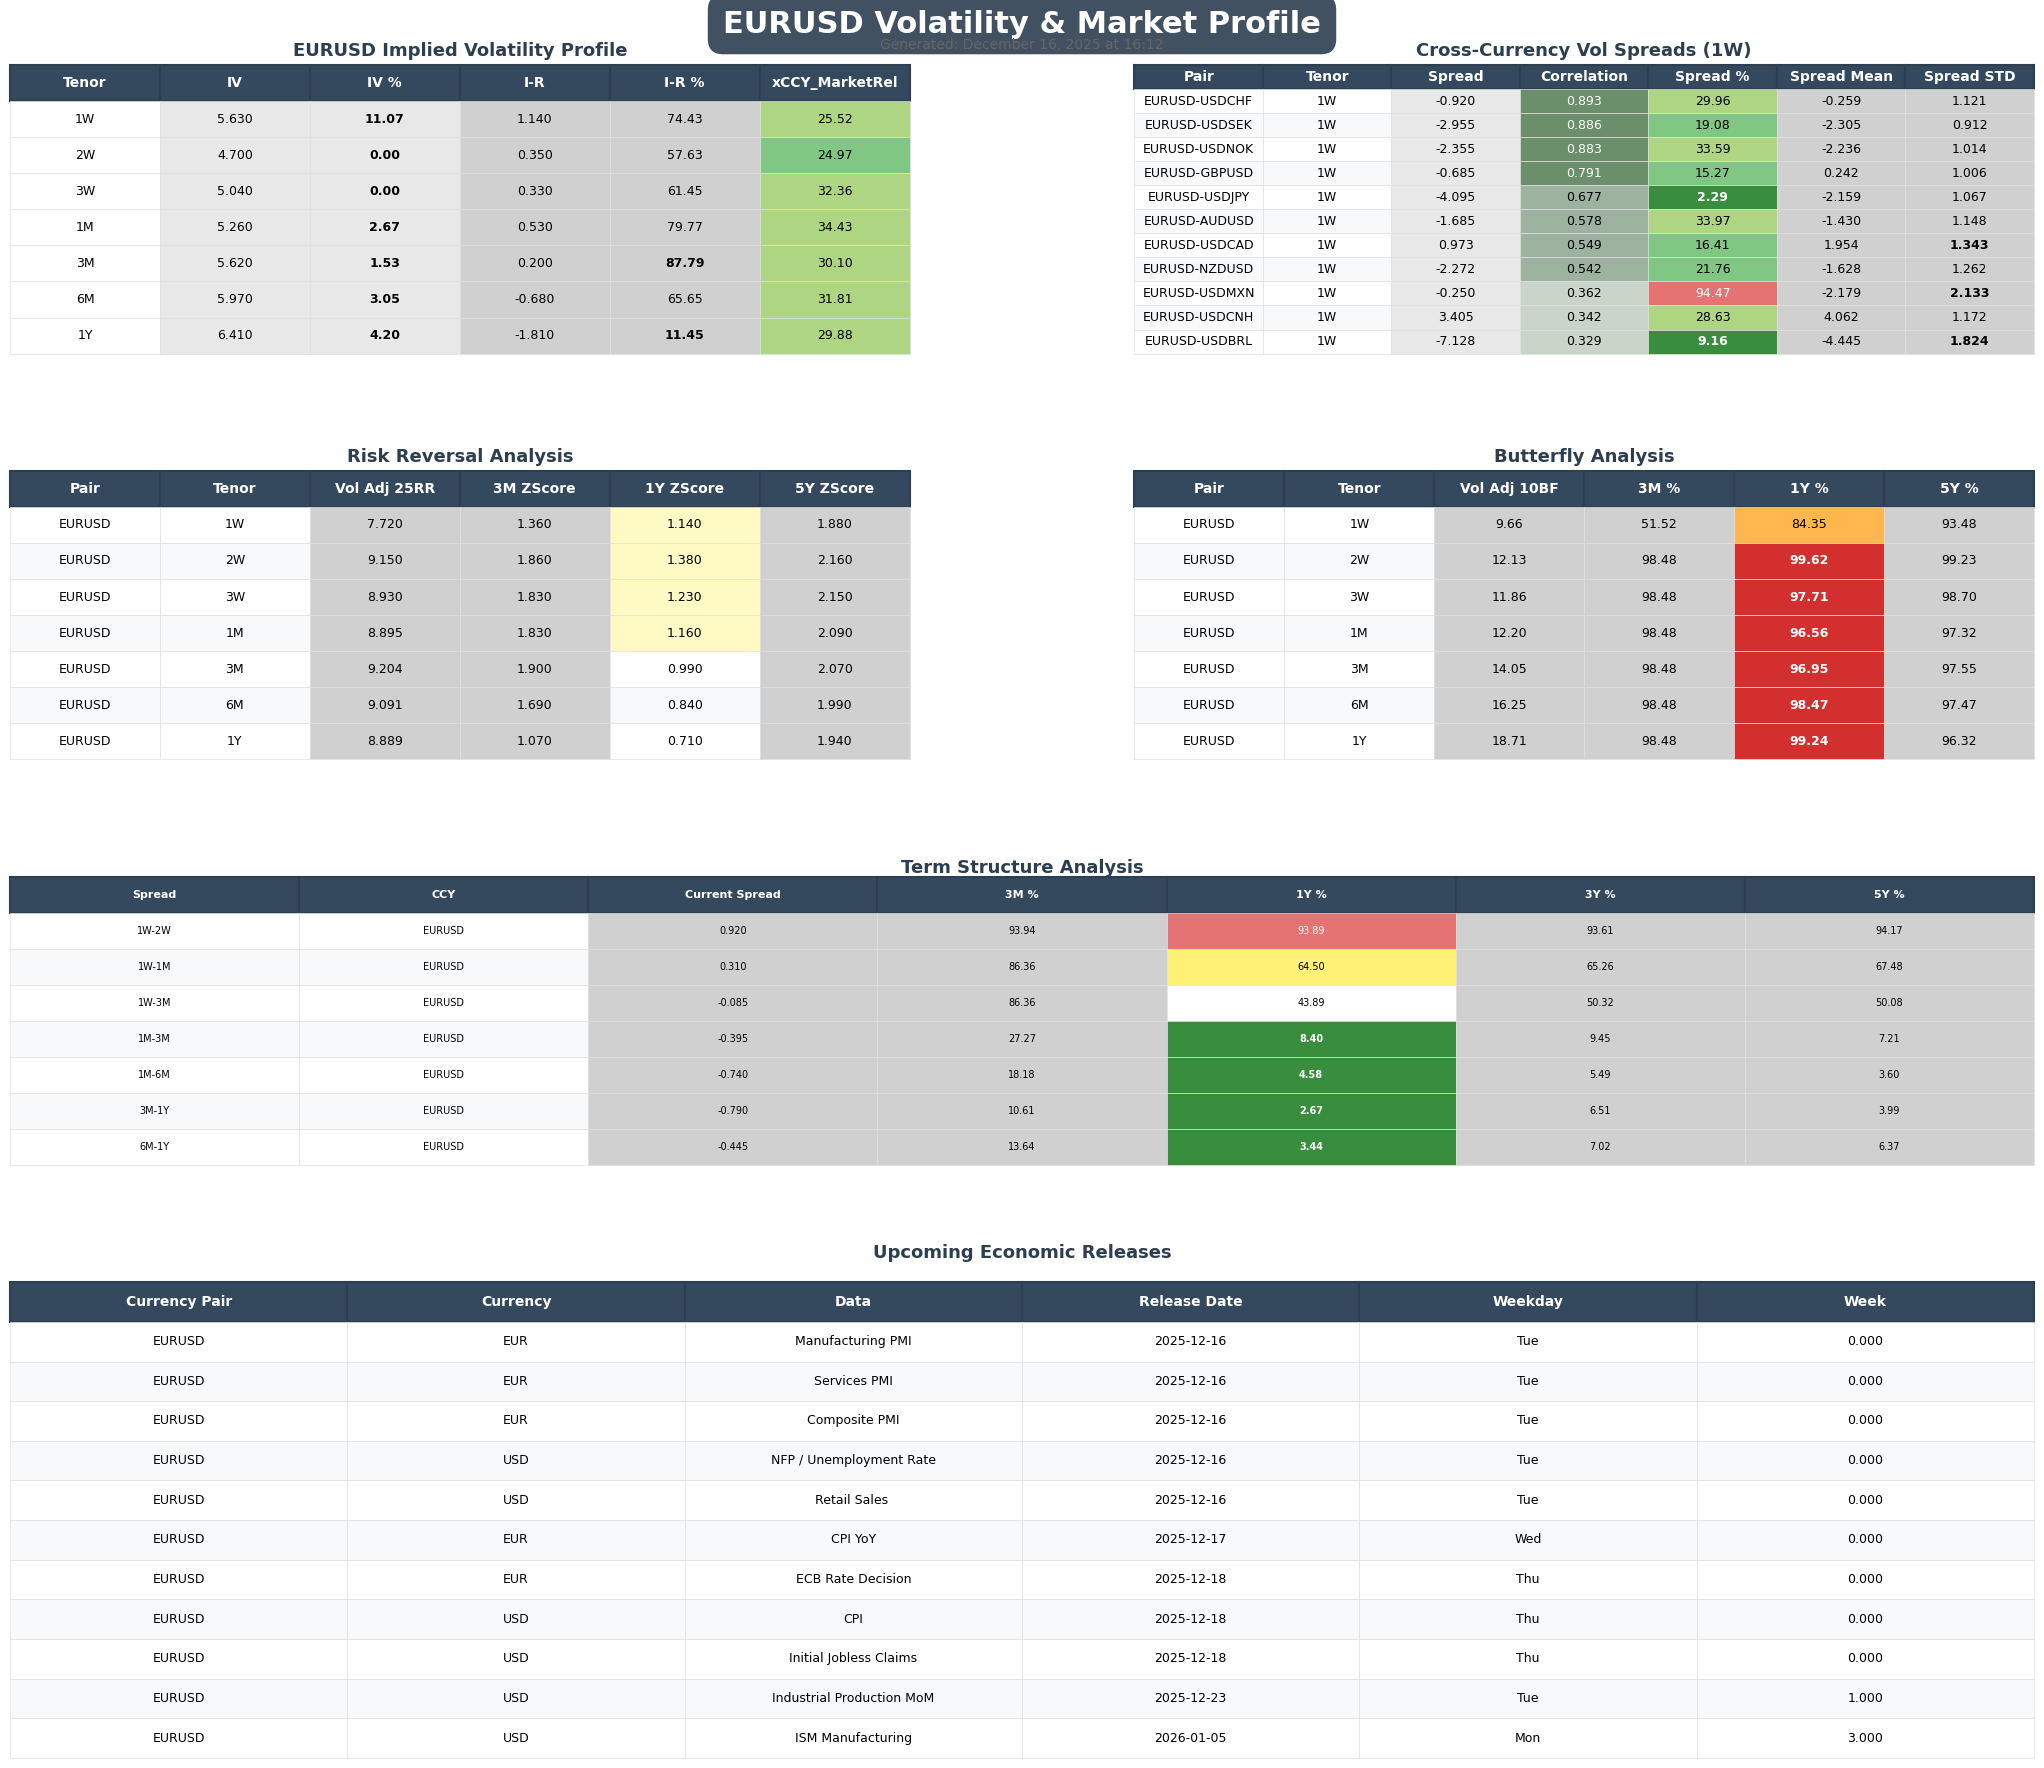

In [ ]:
dashboard = CCYTableDashboard("EURUSD")

# Generate and save
fig = dashboard.create_table_dashboard(
    vol_metrics=xCCY_VolMetrics,
    spreads=xCCY_Spreads,
    rr=df_RR,
    bf=df_BF,
    term_structure=df_termStructure,
    calendar=df_next_releases,
    tenor_for_spreads='1W')

In [ ]:
# look to see if ForecastSDTv has a relationship with Vol of an event

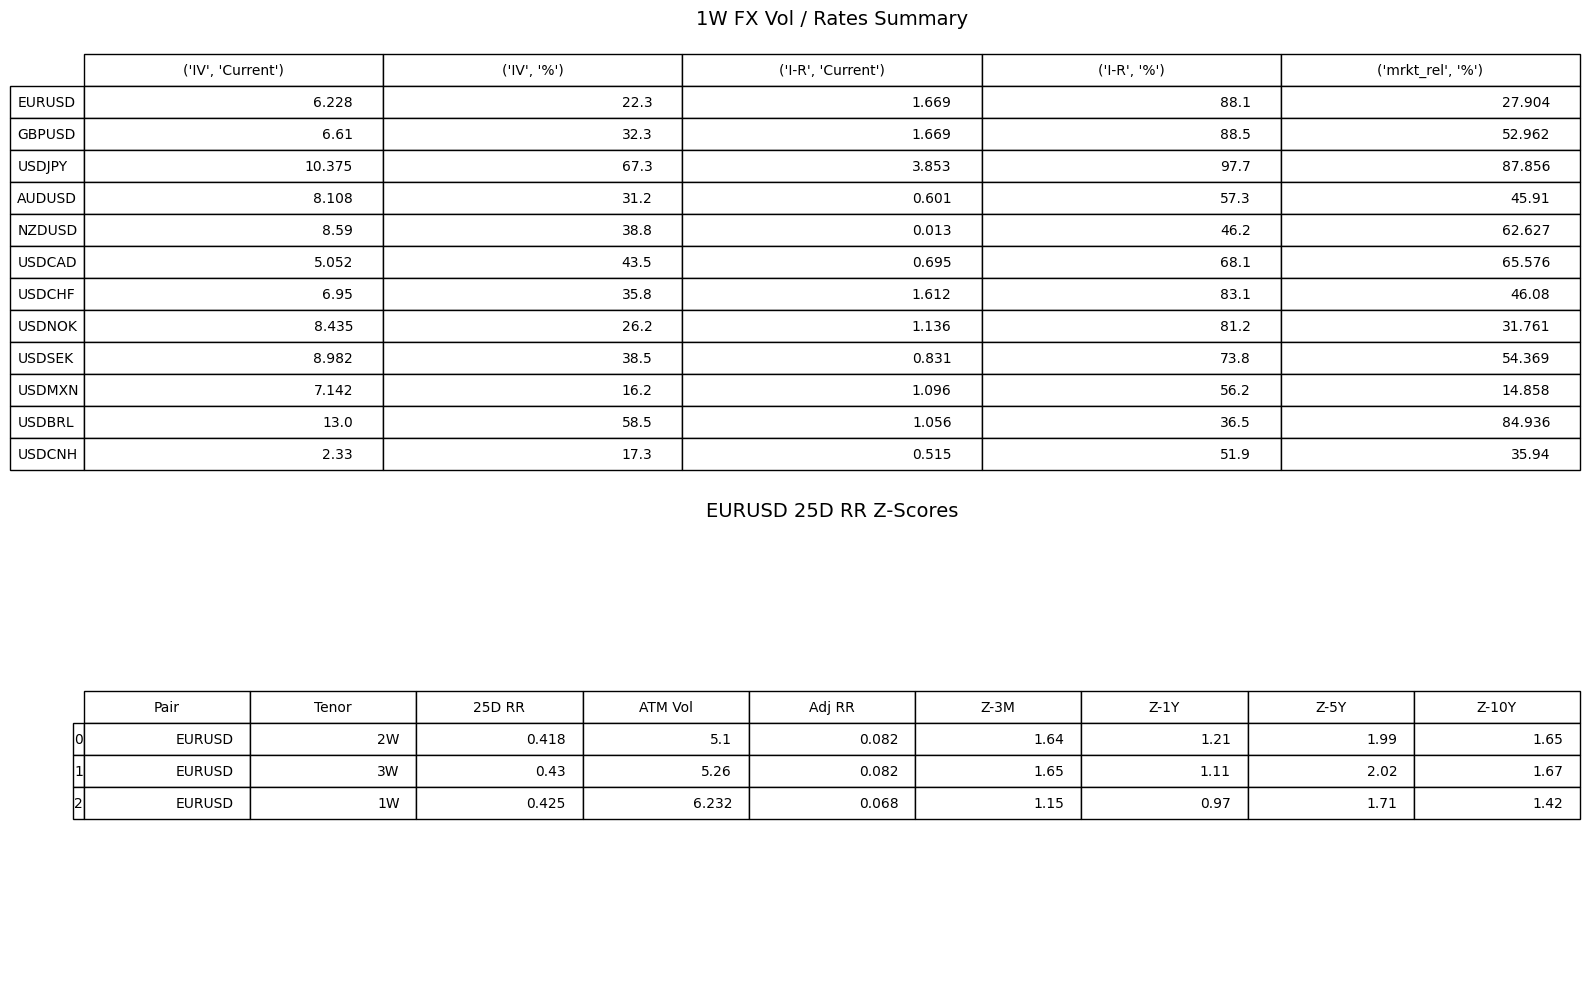

In [12]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(16, 10),
    gridspec_kw={'height_ratios': [1, 1]}
)

# ---------- Top table ----------
axes[0].axis("off")
table1 = axes[0].table(
    cellText=summary["1W"].round(3).values,
    colLabels=summary["1W"].columns,
    rowLabels=summary["1W"].index,
    loc="center"
)
table1.auto_set_font_size(False)
table1.set_fontsize(10)
table1.scale(1, 1.5)
axes[0].set_title("1W FX Vol / Rates Summary", fontsize=14, pad=10)

# ---------- Bottom table ----------
axes[1].axis("off")
table2 = axes[1].table(
    cellText=df.round(3).values,
    colLabels=df.columns,
    rowLabels=df.index,
    loc="center"
)
table2.auto_set_font_size(False)
table2.set_fontsize(10)
table2.scale(1, 1.5)
axes[1].set_title("EURUSD 25D RR Z-Scores", fontsize=14, pad=10)

plt.tight_layout()
plt.show()